# SHAP + Network Analysis

## Purpose: 
{TODO}


## Packages and Options

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import polars as pl 
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

In [2]:
%load_ext autoreload 
%autoreload 2
    
import importlib

SHAP_analysis_class = getattr(
    importlib.import_module("1_shap_network_analyzer"), 
    "ShapNetworkInvestigator"
)


data_modes = ["All-Data", "Unique-Binding"]
binding_modes = ["Bound-Only", "NOT-Bound-Only"]

## Instantiate Class

In [3]:
investigator = SHAP_analysis_class()
investigator.hash_metadata

2025-07-16 11:18:10.113 | SUCCESS  | 1_shap_network_analyzer:make_model_metadata_from_hash:191 - FROM CACHE: loaded hash metadata file


,hash,name,gamma,n_jobs,max_depth,objective,reg_alpha,subsample,reg_lambda,eval_metric,n_estimators,learning_rate,colsample_bytree,min_child_weight,early_stopping_rounds,cell_line,seed,shap_expected_value,alpha,l1_ratio
0,e048c0490ea6f3cfa263c0d3e66e9795583c45a8a5ef2d2715dc08920c13290d,ElasticNet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HepG2,17,NaN,0.000100,1.0
1,d3b95df0842783c0abe226462e97e83be58aa11ed676401dfd640438c3ce1e94,ElasticNet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K562,17,NaN,0.000838,0.1
2,c859f2093367b69aff13a5770150b486a226578fc6f13f1aaacda1b4b145d0c6,XGBRegressor,0.5,-1.0,3.0,reg:logistic,0.0,0.1,1.0,"['rmse', 'logloss']",100000.0,0.05,1.00,30.0,100.0,HepG2,17,1.521426,NaN,NaN
3,3cfd52c46852f8a3afe7b35fc548682916e347a79f66b05f13dec661b727a46b,XGBRegressor,0.5,-1.0,3.0,reg:logistic,0.5,1.0,0.1,"['rmse', 'logloss']",100000.0,0.05,0.75,30.0,100.0,HepG2,17,1.522846,NaN,NaN
4,e94727bc02235363dfbeed3e0818618e62955e5449e3a143e3c560f5e58d0e3c,XGBRegressor,0.5,-1.0,3.0,reg:logistic,0.0,1.0,1.0,"['rmse', 'logloss']",100000.0,0.05,0.75,30.0,100.0,HepG2,17,1.522952,NaN,NaN
5,f784792c7eeb91135eb22d916c79bfbef091e56d2a0a8f4ac8afa92d1e9e1538,XGBRegressor,0.5,-1.0,3.0,reg:logistic,0.5,1.0,10.0,"['rmse', 'logloss']",100000.0,0.05,0.75,30.0,100.0,HepG2,17,1.522858,NaN,NaN
6,fdf52464ba1145bed424d92827c559d851550a0117d96a630474c08e558ac4fd,XGBRegressor,0.5,-1.0,3.0,reg:logistic,0.0,1.0,5.0,"['rmse', 'logloss']",100000.0,0.05,0.75,30.0,100.0,HepG2,17,1.523033,NaN,NaN
7,8f310837d07486fd286d4ad7975dcdd0c2bdfc795d2d59b1bb38f3ecc50044ca,XGBRegressor,0.5,-1.0,5.0,reg:logistic,0.5,1.0,10.0,"['rmse', 'logloss']",100000.0,0.05,0.50,1.0,100.0,K562,17,1.610363,NaN,NaN
8,1a5a622d0e4fb1bc7aeedf84cc41f73cd02c52b204046c305a4746fe7101c069,XGBRegressor,0.5,-1.0,5.0,reg:logistic,0.0,1.0,0.1,"['rmse', 'logloss']",100000.0,0.05,0.50,1.0,100.0,K562,17,1.610020,NaN,NaN
9,f93fa76e4f7b67d2494c9ef5eadbafe3f38bb4f2cad488040116e580f0cc0de2,XGBRegressor,0.5,-1.0,5.0,reg:logistic,0.8,1.0,10.0,"['rmse', 'logloss']",100000.0,0.05,0.50,1.0,100.0,K562,17,1.610097,NaN,NaN


## Create Final SHAP Cache

In [4]:
investigator.load_final_SHAP_data(underlying_data="Unique-Binding")

2025-07-16 11:18:10.208 | WARNING  | 1_shap_network_analyzer:load_final_SHAP_data:4802 - REMINDER: 'All-Data' is used to create cache and Unique-Binding must be created each time from 'All-Data' cache.
2025-07-16 11:18:10.209 | INFO     | 1_shap_network_analyzer:load_final_SHAP_data:4809 - FROM CACHE: Final SHAP data already exists for both cell lines.
2025-07-16 11:19:45.686 | SUCCESS  | 1_shap_network_analyzer:load_final_SHAP_data:4838 - Loaded final SHAP data from cache for Unique-Binding mode.


In [5]:
for key in investigator.final_unique_binding_SHAP_data: 
    investigator.final_unique_binding_SHAP_data[key].shape
    investigator.final_unique_binding_SHAP_data[key].head()

(152196, 1698)

index,AARS_1_binding,AATF_1_binding,ABCF1_1_binding,ADAT1_1_binding,AGGF1_1_binding,AKAP1_1_binding,AKAP8L_1_binding,APEX1_1_binding,APOBEC3C_1_binding,AQR_1_binding,BUD13_1_binding,CPEB4_1_binding,CPSF6_1_binding,CSTF2T_1_binding,DDX1_1_binding,DDX21_1_binding,DDX24_1_binding,DDX3X_1_binding,DDX42_1_binding,DDX43_1_binding,DDX47_1_binding,DDX51_1_binding,DDX52_1_binding,DDX55_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DROSHA_1_binding,EEF2_1_binding,EFTUD2_1_binding,EIF3G_1_binding,EIF4E_1_binding,EIF4G2_1_binding,ELAC2_1_binding,ELAVL1_1_binding,EWSR1_1_binding,EXOSC10_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FMR1_1_binding,FTO_1_binding,FUS_1_binding,FXR1_1_binding,FXR2_1_binding,GARS_1_binding,GEMIN5_1_binding,GNL3_1_binding,GPKOW_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP2_1_binding,ILF3_1_binding,KHDRBS1_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,MBNL1_1_binding,METAP2_1_binding,METTL1_1_binding,MORC2_1_binding,MTPAP_1_binding,NCBP2_1_binding,NIPBL_1_binding,NOLC1_1_binding,NONO_1_binding,NPM1_1_binding,NSUN2_1_binding,PABPC4_1_binding,PCBP1_1_binding,PHF6_1_binding,PPIL4_1_binding,PRPF8_1_binding,PTBP1_1_binding,PUM1_1_binding,PUM2_1_binding,PUS1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RNF187_1_binding,RPS10_1_binding,RPS11_1_binding,RPS3_1_binding,RPS6_1_binding,RYBP_1_binding,SAFB_1_binding,SAFB2_1_binding,SBDS_1_binding,SDAD1_1_binding,SERBP1_1_binding,SF3B1_1_binding,SF3B4_1_binding,SLBP_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,UTP3_1_binding,WDR3_1_binding,WDR43_1_binding,WRN_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,YWHAG_1_binding,ZC3H11A_1_binding,ZC3H8_1_binding,ZNF622_1_binding,ZNF800_1_binding,ZRANB2_1_binding,AARS_2_binding,AATF_2_binding,ABCF1_2_binding,ADAT1_2_binding,AGGF1_2_binding,AKAP1_2_binding,AKAP8L_2_binding,APEX1_2_binding,APOBEC3C_2_binding,AQR_2_binding,BUD13_2_binding,CPEB4_2_binding,CPSF6_2_binding,CSTF2T_2_binding,DDX1_2_binding,DDX21_2_binding,DDX24_2_binding,DDX3X_2_binding,DDX42_2_binding,DDX43_2_binding,DDX47_2_binding,DDX51_2_binding,DDX52_2_binding,DDX55_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DROSHA_2_binding,EEF2_2_binding,EFTUD2_2_binding,EIF3G_2_binding,EIF4E_2_binding,EIF4G2_2_binding,ELAC2_2_binding,ELAVL1_2_binding,EWSR1_2_binding,EXOSC10_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FMR1_2_binding,FTO_2_binding,FUS_2_binding,FXR1_2_binding,FXR2_2_binding,GARS_2_binding,GEMIN5_2_binding,GNL3_2_binding,GPKOW_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP2_2_binding,ILF3_2_binding,KHDRBS1_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,MBNL1_2_binding,METAP2_2_binding,METTL1_2_binding,MORC2_2_binding,MTPAP_2_binding,NCBP2_2_binding,NIPBL_2_binding,NOLC1_2_binding,NONO_2_binding,NPM1_2_binding,NSUN2_2_binding,PABPC4_2_binding,PCBP1_2_binding,PHF6_2_binding,PPIL4_2_binding,PRPF8_2_binding,PTBP1_2_binding,PUM1_2_binding,PUM2_2_binding,PUS1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RNF187_2_binding,RPS10_2_binding,RPS11_2_binding,RPS3_2_binding,RPS6_2_binding,RYBP_2_binding,SAFB_2_binding,SAFB2_2_binding,SBDS_2_binding,SDAD1_2_binding,SERBP1_2_binding,SF3B1_2_binding,SF3B4_2_binding,SLBP_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_bin

(118238, 1290)

index,AGGF1_1_binding,AKAP1_1_binding,AQR_1_binding,BCCIP_1_binding,BCLAF1_1_binding,BUD13_1_binding,CDC40_1_binding,CSTF2_1_binding,CSTF2T_1_binding,DDX3X_1_binding,DDX52_1_binding,DDX55_1_binding,DDX59_1_binding,DDX6_1_binding,DGCR8_1_binding,DHX30_1_binding,DKC1_1_binding,DROSHA_1_binding,EFTUD2_1_binding,EIF3D_1_binding,EIF3H_1_binding,EXOSC5_1_binding,FAM120A_1_binding,FASTKD2_1_binding,FKBP4_1_binding,FTO_1_binding,FUBP3_1_binding,FUS_1_binding,FXR2_1_binding,G3BP1_1_binding,GRSF1_1_binding,GRWD1_1_binding,GTF2F1_1_binding,HLTF_1_binding,HNRNPA1_1_binding,HNRNPC_1_binding,HNRNPK_1_binding,HNRNPL_1_binding,HNRNPM_1_binding,HNRNPU_1_binding,HNRNPUL1_1_binding,IGF2BP1_1_binding,IGF2BP3_1_binding,ILF3_1_binding,KHSRP_1_binding,LARP4_1_binding,LARP7_1_binding,LIN28B_1_binding,LSM11_1_binding,MATR3_1_binding,NCBP2_1_binding,NIP7_1_binding,NKRF_1_binding,NOL12_1_binding,NOLC1_1_binding,NSUN2_1_binding,PABPN1_1_binding,PCBP1_1_binding,PCBP2_1_binding,POLR2G_1_binding,PPIG_1_binding,PRPF4_1_binding,PRPF8_1_binding,PTBP1_1_binding,QKI_1_binding,RBFOX2_1_binding,RBM15_1_binding,RBM22_1_binding,RBM5_1_binding,RPS3_1_binding,SAFB_1_binding,SDAD1_1_binding,SF3A3_1_binding,SF3B4_1_binding,SFPQ_1_binding,SLTM_1_binding,SMNDC1_1_binding,SND1_1_binding,SRSF1_1_binding,SRSF7_1_binding,SRSF9_1_binding,SSB_1_binding,STAU2_1_binding,SUB1_1_binding,SUGP2_1_binding,SUPV3L1_1_binding,TAF15_1_binding,TARDBP_1_binding,TBRG4_1_binding,TIA1_1_binding,TIAL1_1_binding,TRA2A_1_binding,TROVE2_1_binding,U2AF1_1_binding,U2AF2_1_binding,UCHL5_1_binding,UPF1_1_binding,UTP18_1_binding,WDR43_1_binding,XPO5_1_binding,XRCC6_1_binding,XRN2_1_binding,YBX3_1_binding,ZC3H11A_1_binding,ZNF800_1_binding,AGGF1_2_binding,AKAP1_2_binding,AQR_2_binding,BCCIP_2_binding,BCLAF1_2_binding,BUD13_2_binding,CDC40_2_binding,CSTF2_2_binding,CSTF2T_2_binding,DDX3X_2_binding,DDX52_2_binding,DDX55_2_binding,DDX59_2_binding,DDX6_2_binding,DGCR8_2_binding,DHX30_2_binding,DKC1_2_binding,DROSHA_2_binding,EFTUD2_2_binding,EIF3D_2_binding,EIF3H_2_binding,EXOSC5_2_binding,FAM120A_2_binding,FASTKD2_2_binding,FKBP4_2_binding,FTO_2_binding,FUBP3_2_binding,FUS_2_binding,FXR2_2_binding,G3BP1_2_binding,GRSF1_2_binding,GRWD1_2_binding,GTF2F1_2_binding,HLTF_2_binding,HNRNPA1_2_binding,HNRNPC_2_binding,HNRNPK_2_binding,HNRNPL_2_binding,HNRNPM_2_binding,HNRNPU_2_binding,HNRNPUL1_2_binding,IGF2BP1_2_binding,IGF2BP3_2_binding,ILF3_2_binding,KHSRP_2_binding,LARP4_2_binding,LARP7_2_binding,LIN28B_2_binding,LSM11_2_binding,MATR3_2_binding,NCBP2_2_binding,NIP7_2_binding,NKRF_2_binding,NOL12_2_binding,NOLC1_2_binding,NSUN2_2_binding,PABPN1_2_binding,PCBP1_2_binding,PCBP2_2_binding,POLR2G_2_binding,PPIG_2_binding,PRPF4_2_binding,PRPF8_2_binding,PTBP1_2_binding,QKI_2_binding,RBFOX2_2_binding,RBM15_2_binding,RBM22_2_binding,RBM5_2_binding,RPS3_2_binding,SAFB_2_binding,SDAD1_2_binding,SF3A3_2_binding,SF3B4_2_binding,SFPQ_2_binding,SLTM_2_binding,SMNDC1_2_binding,SND1_2_binding,SRSF1_2_binding,SRSF7_2_binding,SRSF9_2_binding,SSB_2_binding,STAU2_2_binding,SUB1_2_binding,SUGP2_2_binding,SUPV3L1_2_binding,TAF15_2_binding,TARDBP_2_binding,TBRG4_2_binding,TIA1_2_binding,TIAL1_2_binding,TRA2A_2_binding,TROVE2_2_binding,U2AF1_2_binding,U2AF2_2_binding,UCHL5_2_binding,UPF1_2_binding,UTP18_2_binding,WDR43_2_binding,XPO5_2_binding,XRCC6_2_binding,XRN2_2_binding,YBX3_2_binding,ZC3H11A_2_binding,ZNF800_2_binding,AGGF1_3_binding,AKAP1_3_binding,AQR_3_binding,BCCIP_3_binding,BCLAF1_3_binding,BUD13_3_binding,CDC40_3_binding,CSTF2_3_binding,CSTF2T_3_binding,DDX3X_3_binding,DDX52_3_binding,DDX55_3_binding,DDX59_3_binding,DDX6_3_binding,DGCR8_3_binding,DHX30_3_binding,DKC1_3_binding,DROSHA_3_binding,EFTUD2_3_binding,EIF3D_3_binding,EIF3H_3_binding,EXOSC5_3_binding,FAM120A_3_binding,FASTKD2_3_binding,FKBP4_3_binding,FTO_3_binding,FUBP3_3_binding,FUS_3_binding,FXR2_3_binding,G3BP1_3_binding,GRSF1_3_binding,GRWD1_3_binding,GTF2F1_3_binding,HLTF_3_binding,HNRNPA1_3_binding,HNRNPC_3_binding,HNRNPK_3_binding,HNRNPL_3_binding,HNRNPM_3_

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Predicted vs Actual Plots</h1>

In [ ]:
for mode in data_modes

    investigator.plot_actual_vs_predicted_for_best_models(underlying_data = mode)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Binding Sum Distribution</h1>

/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/6_SHAP_network_analysis/code/1_shap_network_analyzer.py:5411: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  y="Binding Sum",
/sfs/gpfs/tardis/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/6_SHAP_network_analysis/code/1_shap_network_analyzer.py:5411: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  y="Binding Sum",


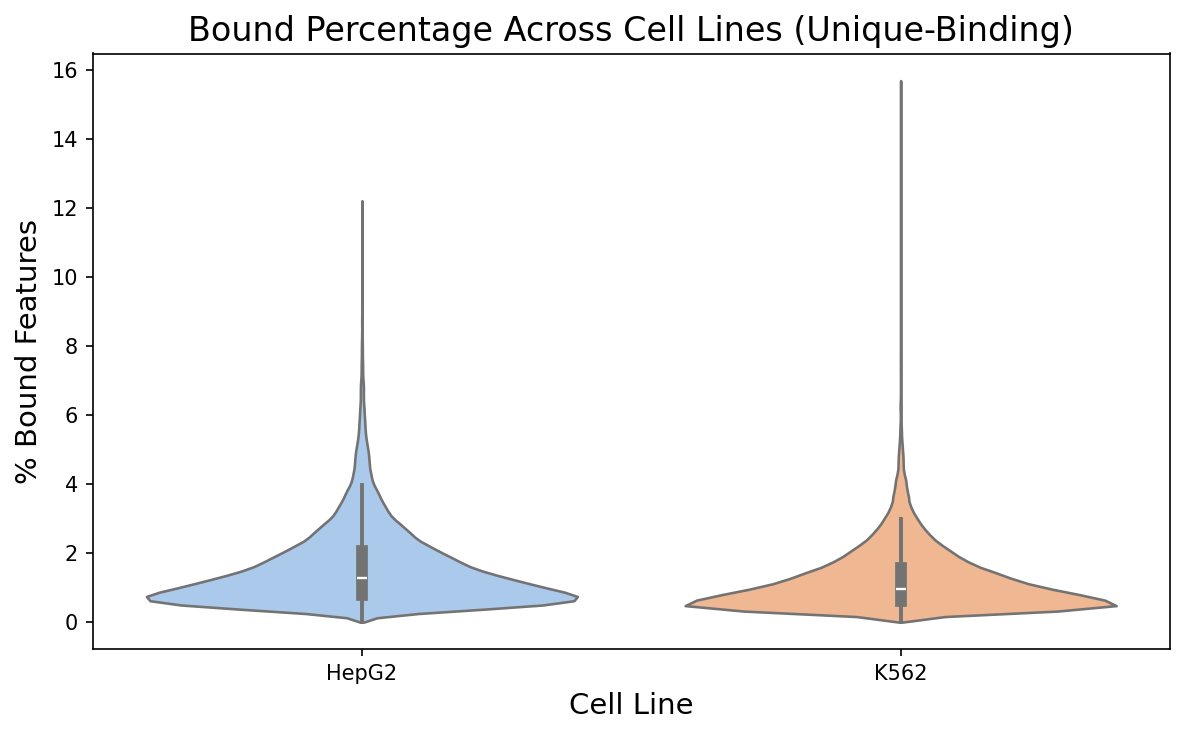

In [8]:
investigator.plot_binding_sum_distribution()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">View Feature Distribution of Local SHAP</h1>

In [ ]:
# investigator.plot_local_SHAP_distribution_per_feature_as_mp4()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Global SHAP Across Models and for Average Local SHAP</h1>

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs", binding_unique="All-Data")

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="All-Data")

In [ ]:
tables = investigator.plot_global_SHAP_mean_vs_variance(mode="5_dfs", binding_unique="Unique-Binding")

for key in tables: 
    key 
    tables[key].head()


In [ ]:
investigator.plot_global_SHAP_coefficient_of_variation(mode='5_dfs', binding_unique="Unique-Binding")

In [ ]:
investigator.plot_global_SHAP_distributions_across_binding_modes()

In [ ]:
investigator.plot_global_SHAP_examples_as_bar_plots(mode = "Bound-Only", underlying_data="Unique-Binding")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Local SHAP Variance Analysis</h1>

In [ ]:
investigator.plot_SHAP_CV()

In [ ]:
investigator.plot_SHAP_std()

In [ ]:
investigator.plot_local_SHAP_mean_vs_variance()

In [ ]:
decile_types = ["Bound-Only", "NOT-Bound-Only", '5_dfs_average']

for mode in decile_types: 
    mode
    investigator.calculate_local_SHAP_mean_vs_variance_deciles(mode=mode)

<h1 style="color: teal; font-weight: bold; font-size: 48px;">ElasticNet</h1>


In [ ]:
elasticnet = investigator.load_elasticnet_coefficients()

for key in elasticnet: 
    key 
    elasticnet[key]["coefficients"].head()

In [ ]:
investigator.plot_elasticnet_coefficients()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Position 3 + 4 Significance in Global SHAP/ElasticNet</h1>


In [ ]:
investigator.check_position_3_and_4_significance_for_global_SHAP_and_elasticnet()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Check Variance of Local SHAP per Unique Binding Pattern</h1>

In [ ]:
table = investigator.check_no_SHAP_variance_per_binding_pattern()

In [ ]:
table.sample(10)
table["num_unique_shap_rows"].value_counts()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Make Global SHAP Plots with Variations</h1>

# Variations: 
* Unique Binding Patterns 
* Feature is bound
* Feature is NOT bound
* Feature is NOT bound in CONTROL
* Feature is NOT bound in ROW W/ RBP KD AT ANY POSITION
* Feature is NOT bound in ROW W/ RBP KD AT SPECIFIC POSITION

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs", binding_unique="Unique-Binding")

In [ ]:
tables = investigator.plot_global_SHAP_mean_vs_variance(mode="5_dfs", binding_unique="Unique-Binding")

for key in tables: 
    key 
    tables[key].head()

In [ ]:
investigator.plot_global_SHAP(mode="5_dfs_average", binding_unique="Unique-Binding")

In [ ]:
investigator.plot_global_SHAP_between_unique_binding_and_all_data()

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="Bound-Only", condition=None, underlying_data="Unique-Binding")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="Bound-Only", binding_unique="All-Data")

In [ ]:
investigator.plot_global_SHAP(mode="Bound-Only", binding_unique="Unique-Binding")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition=None, underlying_data="Unique-Binding")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only", binding_unique="Unique-Binding")

In [ ]:
investigator.plot_specialized_vs_regular_global_SHAP()

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="CTRL")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-CTRL", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="RBP_KD")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-RBP_KD", binding_unique="All-Data")

In [ ]:
tables = investigator.calculate_specialized_global_SHAP(mode="NOT-Bound-Only", condition="RBP_KD_at_position")
for key in tables: 
    tables[key]

In [ ]:
investigator.plot_global_SHAP(mode="NOT-Bound-Only-RBP_KD_at_position", binding_unique="All-Data")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Local SHAP Sign Analysis</h1>

# Includes: 


* Percentage of local SHAP that is non-zero at different cutoffs
* Percentage of local SHAP positive/negative either when feature is bound or unbound
* Understanding activation and repression through custom metric

## % Non-Zero SHAP

In [ ]:
for mode in data_modes
    investigator.calculate_local_SHAP_percent_non_zero(mode=mode).head()

In [ ]:
investigator.plot_local_SHAP_percent_non_zero()

## Negative & Positive Local SHAP

In [ ]:
investigator.calculate_percent_positive_and_negative_local_SHAP_per_feature(mode = "NOT-Bound-Only", underlying_data="Unique-Binding")
investigator.calculate_percent_positive_and_negative_local_SHAP_per_feature(mode = "Bound-Only", underlying_data="Unique-Binding")


In [ ]:
investigator.plot_percent_positive_and_negative_local_SHAP_per_feature(underlying_data="Unique-Binding")

## Custom Metric for Activation and Repression Behavioral Understanding

In [ ]:
for binding_mode in ["Bound-Only", "NOT-Bound-Only"]: 
    investigator.calculate_activator_repressor_behavior_score(binding_mode=binding_mode, underlying_data="Unique-Binding").head()

In [ ]:
investigator.plot_activator_repressor_behavior_score(underlying_data = "Unique-Binding")

In [ ]:
investigator.plot_activator_repressor_behavior_score_vs_percent_positive_and_negative(underlying_data="Unique-Binding")

<h1 style="color: red; font-weight: bold; font-size: 60px;">INCOMPLETE</h1>

<h1 style="color: teal; font-weight: bold; font-size: 48px;">SHAP for Zero Binding Rows</h1>

Looks at: 

* Heatmap of `NOT Bound` "`Global SHAP`" for rows of: 
    * Control
    * The KD of the RBP for that feature
    * That feature having in-silico knockdown 

<br>


* Heatmap of % of zero binding events that have "0" `Local SHAP`

<br>

In [ ]:
investigator.shap_for_zero_binding_features_by_condition()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Differential Splicing Events</h1>

### Focuses on: 

* RBP-specific: 
    * \# Significant Diff Events 
    * \# Significant Diff Events w/ RBP KD at **ANY** Position
* Feature-specific: 
    * \# Significant Diff Events w/ RBP KD at **SPECIFIC** Position



In [ ]:
investigator.create_feature_metric_summary_table()

In [ ]:
investigator.plot_differential_splicing_types()


In [ ]:
investigator.plot_differential_ranks()

In [ ]:
investigator.plot_differential_ratios()

In [ ]:
investigator.plot_matching_differential_ratios_scatterplot()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Metric w/ Regulatory Explanation</h1>

* `Global SHAP`
* `ElasticNet coefficients`
* `Total Binding`
* `# Differential Events`

In [ ]:
investigator.plot_feature_metric_summary_table()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Hacky, Quick, and Dirty Analysis</h1>

In [ ]:
investigator.hacky_not_bound_global_SHAP_by_number_binding()

In [ ]:
investigator.hacky_plot_bound_unbound_signed_local_SHAP_vs_PSI()

In [ ]:
investigator.hacky_plot_bound_unbound_all_data_vs_unique_binding_global_SHAP()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Choose Examples Showcasing Local SHAP and PSI Concordance</h1>


In [ ]:
investigator.plot_local_SHAP_vs_PSI(feature="AQR_4_shap", data_mode="All-Data")